In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import *

In [2]:
df = pd.read_csv("../../Data/job_salary_prediction_dataset.csv")

In [3]:
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [4]:
X =  df.drop('salary', axis=1)
y = df['salary']

In [5]:
X.shape, y.shape

((250000, 9), (250000,))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

In [8]:
X_train.shape, X_test.shape

((200000, 9), (50000, 9))

In [9]:
#  Standardscaling: 
df[['experience_years', 'salary']]

,experience_years,salary
0,10,109413
1,5,93764
2,18,148123
3,19,189123
4,15,165069
...,...,...
249995,17,127791
249996,20,154593
249997,1,75988
249998,0,90467


In [12]:
#  Standardscaling: 
df[['experience_years', 'salary']]

,experience_years,salary
0,10,109413
1,5,93764
2,18,148123
3,19,189123
4,15,165069
...,...,...
249995,17,127791
249996,20,154593
249997,1,75988
249998,0,90467


In [19]:
# np.sqrt(np.square(np.array([10, 104913])).sum()))

np.float64(104923.0)

In [32]:
scale = StandardScaler()
# arr = scale.fit_transform(pd.DataFrame(y_train)) 
arr = scale.fit_transform(df[['experience_years', 'salary']]) 

In [33]:
arr

array([[-8.92322321e-04, -9.70519649e-01],
       [-8.25894468e-01, -1.38885399e+00],
       [ 1.31911111e+00,  6.42891180e-02],
       ...,
       [-1.48589618e+00, -1.86404801e+00],
       [-1.65089661e+00, -1.47699051e+00],
       [ 9.89110253e-01, -3.37738499e-01]], shape=(250000, 2))

In [22]:
import matplotlib.pyplot as plt

<Axes: ylabel='Density'>

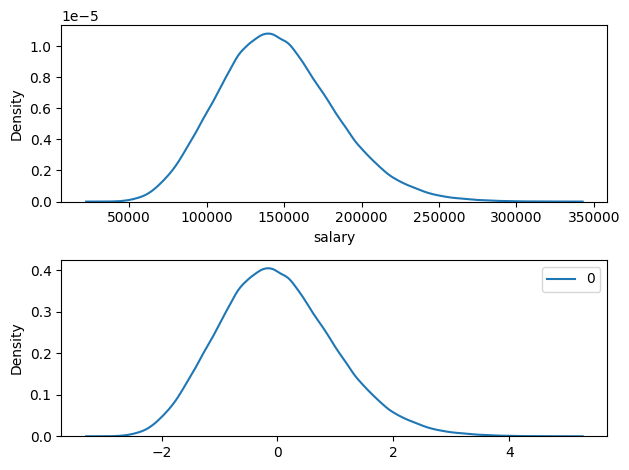

In [30]:
fig, ax = plt.subplots( 2, layout='tight')
sns.kdeplot(y_train, ax=ax[0])
sns.kdeplot(arr, ax=ax[1])

<Axes: ylabel='Density'>

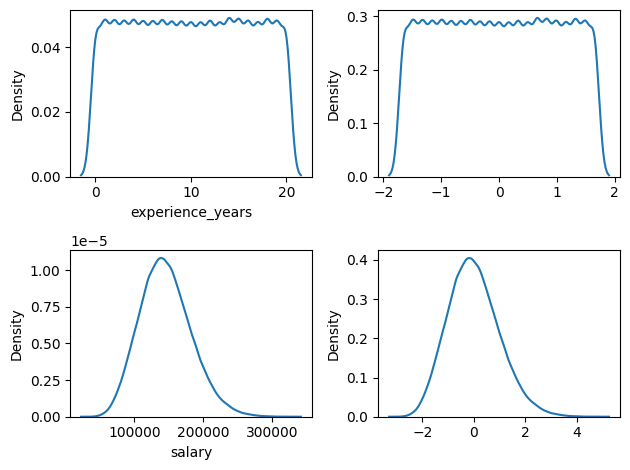

In [37]:
fig, ax = plt.subplots( 2,2, layout='tight')
sns.kdeplot(df['experience_years'], ax=ax[0,0])
sns.kdeplot(arr[:, 0], ax=ax[0, 1])
sns.kdeplot(df['salary'], ax=ax[1,0])
sns.kdeplot(arr[:, 1], ax=ax[1, 1])

In [38]:
# robustscaler 
sc = RobustScaler()
sc.fit_transform(df[['experience_years', 'salary']]) 

array([[ 0.        , -0.67898033],
       [-0.5       , -0.99112379],
       [ 0.8       ,  0.09315036],
       ...,
       [-0.9       , -1.34569354],
       [-1.        , -1.05688754],
       [ 0.6       , -0.20682571]], shape=(250000, 2))

In [39]:
# get_feature_names_out
# feature_names_in 
# inverse_transform() # array -> orignal # arr 2D
sc.inverse_transform([[ 0.        , -0.67898033],
       [-0.5       , -0.99112379],
       [ 0.8       ,  0.09315036]])

array([[1.00000000e+01, 1.09413000e+05],
       [5.00000000e+00, 9.37639999e+04],
       [1.80000000e+01, 1.48123000e+05]])

In [46]:
# normalization :MinMaxScaling
# x - xmin / xmax - xmin  # bounded scaling 0-1
sc = MinMaxScaler((100, 110))
sc.fit_transform(df[['experience_years', 'salary']])

array([[105.        , 102.57474791],
       [102.5       , 102.05515657],
       [109.        , 103.86003008],
       ...,
       [100.5       , 101.46494277],
       [100.        , 101.94568678],
       [108.        , 103.36069248]], shape=(250000, 2))

In [59]:
# norm 
norm = Normalizer('max') # l2
arr =norm.fit_transform(df[['experience_years', 'salary']])


In [60]:
np.linalg.norm(arr[0, :])

np.float64(1.000000004176689)

In [61]:
arr

array([[9.13968176e-05, 1.00000000e+00],
       [5.33253701e-05, 1.00000000e+00],
       [1.21520628e-04, 1.00000000e+00],
       ...,
       [1.31599726e-05, 1.00000000e+00],
       [0.00000000e+00, 1.00000000e+00],
       [1.20224820e-04, 1.00000000e+00]], shape=(250000, 2))

In [62]:
norm.get_feature_names_out()

array(['experience_years', 'salary'], dtype=object)

In [63]:
norm.feature_names_in_

array(['experience_years', 'salary'], dtype=object)

In [66]:
data = df[~(df['remote_work']=="Hybrid")].copy()

In [67]:
data

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
5,AI Engineer,0,High School,4,Education,Enterprise,USA,No,2,180351
...,...,...,...,...,...,...,...,...,...,...
249994,Business Analyst,13,Diploma,17,Finance,Large,USA,Yes,3,171896
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988


In [71]:
data.loc[data['remote_work']=='Yes', 'remote_work'] = 'True'
data.loc[data['remote_work']=='No', 'remote_work'] = 'False'

In [72]:
data['remote_work'] = data['remote_work'].astype('bool')

In [79]:
binn = Binarizer(threshold=0.5) 
binn.fit_transform(data[['certifications']])

array([[0],
       [1],
       [0],
       ...,
       [1],
       [0],
       [1]], shape=(166524, 1))

In [ ]:
# binning 